# **Applied Machine Learning Lab-(MCSE630P)**

**Assignment 7-Numerical input feature selection (Anova and mutual information)**

**Name:** Shrihariharan S [24MCS1058]

Experiment anova and mutual information based feature selection on the data set. Build the model with all features and subset of features obtained using anova and mutual information and compare the performances and provide your inferences.

Kaggle dataset:https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression

In [227]:
! pip install -q kaggle

In [228]:
!mkdir ~/.kaggle
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [229]:
! chmod 600 ~/.kaggle/kaggle.json

In [230]:
! kaggle datasets list

ref                                                            title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
lainguyn123/student-performance-factors                        Student Performance Factors                          94KB  2024-09-02 10:53:57          24971        446  1.0              
abdulszz/spotify-most-streamed-songs                           Spotify Most Streamed Songs                          60KB  2024-09-07 18:23:14           8991        116  1.0              
valakhorasani/mobile-device-usage-and-user-behavior-dataset    Mobile Device Usage and User Behavior Dataset        11KB  2024-09-28 20:21:12           2221         55  1.0              
asmonline/spotify-song-performance-dataset                     Sp

In [231]:
! kaggle datasets download -d dileep070/heart-disease-prediction-using-logistic-regression

Dataset URL: https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression
License(s): unknown
heart-disease-prediction-using-logistic-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [232]:
#unzipping the downloaded file
import zipfile
f=zipfile.ZipFile('/content/heart-disease-prediction-using-logistic-regression.zip','r')
f.extractall('/content')
f.close()

In [233]:
#exporting Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from pandas.core.common import random_state

In [234]:
#reading the csv file and storing it in the dataframe hd
hd=pd.DataFrame(pd.read_csv("/content/framingham.csv"))

In [235]:
hd.head() # first 5 values of dataset

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [236]:
hd['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3594
1,644


In [237]:
hd.describe() # describes the mean,median,min,max of the dataset

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [238]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [239]:
hd.isnull().sum() #checkinhg for null values

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [240]:
hd=hd.drop('education',axis=1) #dropping the column education

In [241]:
hd['age'].fillna(hd['age'].mean(), inplace=True)  # Replace with median for skewed data

<ipython-input-241-ddb9af7a338e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hd['age'].fillna(hd['age'].mean(), inplace=True)  # Replace with median for skewed data


In [242]:
hd['BPMeds'].fillna(hd['BPMeds'].mode()[0], inplace=True)

<ipython-input-242-509dafe1c598>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hd['BPMeds'].fillna(hd['BPMeds'].mode()[0], inplace=True)


In [243]:
hd.isnull().sum() #checkinhg for null values

,0
male,0
age,0
currentSmoker,0
cigsPerDay,29
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50
sysBP,0


In [244]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
hd_imputed = pd.DataFrame(imputer.fit_transform(hd), columns=hd.columns)

In [245]:
# Step 1: Set cigsPerDay to 0 for non-smokers (currentSmoker == 0)
hd.loc[hd['currentSmoker'] == 0, 'cigsPerDay'] = 0

# Step 2: Impute missing values for smokers (currentSmoker == 1) using the median of smokers' cigsPerDay
median_cigs_for_smokers = hd[hd['currentSmoker'] == 1]['cigsPerDay'].median()
hd.loc[hd['currentSmoker'] == 1, 'cigsPerDay'] = hd.loc[hd['currentSmoker'] == 1, 'cigsPerDay'].fillna(median_cigs_for_smokers)

In [246]:
hd['totChol'].fillna(hd['totChol'].median(), inplace=True)

<ipython-input-246-43bf4ff16a4e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hd['totChol'].fillna(hd['totChol'].median(), inplace=True)


In [247]:
hd['heartRate'] = hd.groupby('age')['heartRate'].transform(lambda x: x.fillna(x.median()))

In [248]:
hd['BMI'].fillna(hd['BMI'].median(), inplace=True)

<ipython-input-248-5d0442586bd4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hd['BMI'].fillna(hd['BMI'].median(), inplace=True)


In [249]:
hd['glucose'].fillna(hd['glucose'].median(), inplace=True)

<ipython-input-249-18fc5738f4b3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hd['glucose'].fillna(hd['glucose'].median(), inplace=True)


In [250]:
hd.isnull().sum() #checkinhg for null values

,0
male,0
age,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0
sysBP,0


In [251]:
X=hd.drop('TenYearCHD',axis=1)
y=hd['TenYearCHD']

In [252]:
pd.DataFrame(X)

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0
4235,0,48,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0


In [253]:
pd.DataFrame(y)

,TenYearCHD
0,0
1,0
2,0
3,1
4,0
...,...
4233,1
4234,0
4235,0
4236,0


In [254]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=1)

In [255]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2839, 14), (1399, 14), (2839,), (1399,))

In [256]:
 #importing packages
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from matplotlib import pyplot

In [257]:
#ANOVA F_statistic score based feature selection
def select_features(X_train,y_train,X_test):
    fs=SelectKBest(score_func=f_classif,k=4)
    fs.fit(X_train,y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs,X_test_fs,fs

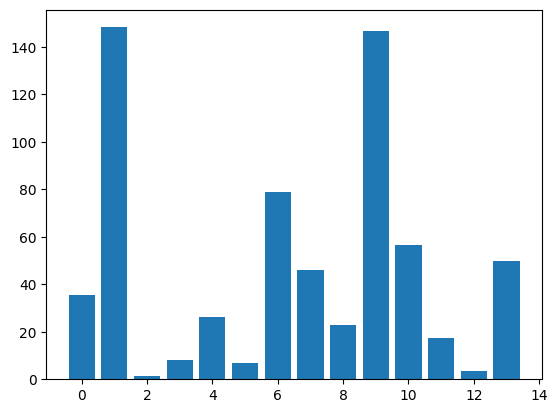

In [258]:
#Selecting best features and plotting
X_train_fs,X_test_fs,fs=select_features(X_train,y_train,X_test)
pyplot.bar([i for i in range(len(fs.scores_))],fs.scores_)
pyplot.show()

In [259]:
#feature scores
fs.scores_

array([ 35.59078317, 148.29050895,   1.53899909,   8.06833562,
        26.34942457,   6.91178367,  78.70997135,  46.00263233,
        22.9508819 , 146.89593608,  56.65474827,  17.58041587,
         3.50053625,  49.70872449])

In [260]:
from sklearn.feature_selection import mutual_info_classif

In [261]:
#Mutual information based feature selection
def select_features_2(X_train,y_train,X_test):
    fs=SelectKBest(score_func=mutual_info_classif,k=4)
    fs.fit(X_train,y_train)
    X_train_fs=fs.transform(X_train)
    X_test_fs=fs.transform(X_test)
    return X_train_fs,X_test_fs,fs

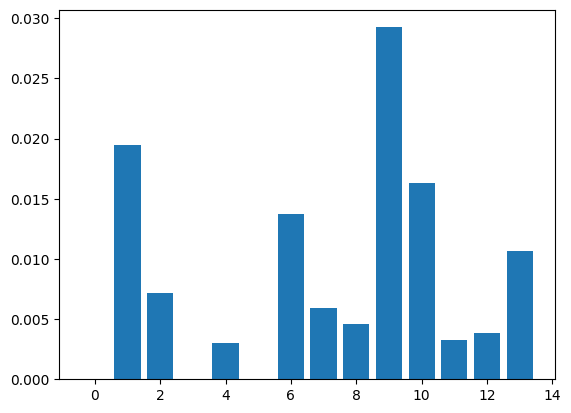

In [262]:
#Selecting best features using MI and plotting
X_train_fs2,X_test_fs2,fs2=select_features_2(X_train,y_train,X_test)
pyplot.bar([i for i in range(len(fs2.scores_))],fs2.scores_)
pyplot.show()

In [263]:
#Building model with all features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [264]:
model1=LogisticRegression(solver='liblinear')
model1.fit(X_train,y_train)
yhat=model1.predict(X_test)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 86.63


In [265]:
#Model built using features chosen with ANOVA F-statistic
model2=LogisticRegression(solver='liblinear')
model2.fit(X_train_fs,y_train)
yhat=model2.predict(X_test_fs)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 86.85


In [266]:
#Model built using features chosen with Mutual information
model3=LogisticRegression(solver='liblinear')
model3.fit(X_train_fs2,y_train)
yhat=model3.predict(X_test_fs2)
accuracy=accuracy_score(y_test,yhat)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 86.85


In [267]:
#comparing different no. of features selected using ANOVA f-test
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_val_score

In [268]:
def evaluate_model(pipeline):
    cv=RepeatedStratifiedKFold(n_repeats=3,n_splits=10, random_state=1)
    scores=cross_val_score(pipeline,X,y,scoring='accuracy',cv=cv,n_jobs=1)
    return scores

#1 0.848 (0.001)
#2 0.849 (0.002)
#3 0.849 (0.001)
#4 0.850 (0.002)
#5 0.850 (0.003)
#6 0.849 (0.003)
#7 0.850 (0.003)
#8 0.851 (0.003)
#9 0.851 (0.003)
#10 0.851 (0.004)
#11 0.852 (0.004)
#12 0.853 (0.004)
#13 0.853 (0.005)
#14 0.853 (0.005)


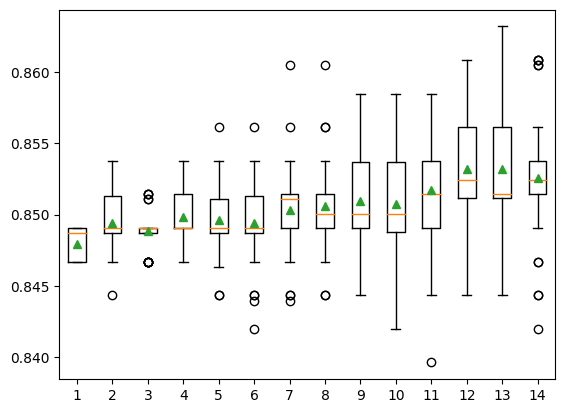

In [269]:
num_features=[i+1 for i in range(X.shape[1])]

#enumerate each no. of feature
results=list()
for k in num_features:
    #create pipeline
    model=LogisticRegression(solver='liblinear')
    fs=SelectKBest(score_func=f_classif,k=k)
    pipeline=Pipeline(steps=[('anova',fs),('lr',model)])

    #evaluate the model
    scores=evaluate_model(pipeline)
    results.append(scores)

    print('#%d %.3f (%.3f)' %(k,mean(scores),std(scores)))
pyplot.boxplot(results, labels=num_features, showmeans=True)
pyplot.show()

#**Additional Learning (using ensemblers)**

In [270]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

In [271]:
from sklearn.model_selection import cross_val_score

# Set up K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

# Train the model using cross-validation and calculate scores
scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')  # You can use other metrics like 'f1', 'roc_auc', etc.

# Print the scores and the mean accuracy across all folds
print(f'Accuracy per fold: {scores}')
print(f'Average accuracy: {scores.mean()}')


Accuracy per fold: [0.85849057 0.85613208 0.85141509 0.84769776 0.85123967]
Average accuracy: 0.852995032411842


In [272]:
cv=RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=1)

In [273]:
model=LogisticRegression(solver='liblinear')
fs=SelectKBest(score_func=f_classif)
pipeline1=Pipeline(steps=[('anova',fs),('lr',model)])

In [274]:
grid=dict()
grid['anova__k']=[i+1 for i in range(X.shape[1])]

In [275]:
search=GridSearchCV(pipeline1, grid, scoring='accuracy',n_jobs=-1, cv=cv)
results=search.fit(X,y)

In [276]:
print('Best Mean Accuracy: %.3f' % results.best_score_)
print('Best config %s' %results.best_params_)

Best Mean Accuracy: 0.853
Best config {'anova__k': 13}


In [277]:
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  # Standardizing the data
    ('classifier', RandomForestClassifier(random_state=42))  # Model
])

**Using Bagging: Random Forest Classifier**

In [278]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [279]:
y_pred = pipeline.predict(X_test)

In [280]:
accuracy_score(y_test, y_pred)

0.8613295210864903

In [281]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [282]:
pipeline.fit(X_train_fs,y_train)
yhat1=pipeline.predict(X_test_fs)
accuracy=accuracy_score(y_test,yhat1)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 84.35


In [283]:
pipeline.fit(X_train_fs,y_train)
yhat1=pipeline.predict(X_test_fs2)
accuracy=accuracy_score(y_test,yhat1)
print("Accuracy: %.2f" %(accuracy*100))

Accuracy: 84.35


**Using Boosting: Gradient Boosting Classifier**

In [284]:
from sklearn.ensemble import GradientBoostingClassifier

In [285]:
pipeline_gb = Pipeline(steps=[
    ('scaler', StandardScaler()),  # Standardizing the data
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))  # Gradient Boosting model
])

In [286]:
pipeline_gb.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [287]:
y_pred_boost = pipeline_gb.predict(X_test)

In [288]:
accuracy_score(y_test, y_pred_boost)

0.8613295210864903

In [289]:
pipeline_gb.fit(X_train_fs, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [290]:
y_pred_boost1 = pipeline_gb.predict(X_test_fs)

In [291]:
accuracy_score(y_test, y_pred_boost1)

0.8634739099356683

In [292]:
pipeline_gb.fit(X_train_fs2, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [293]:
y_pred_boost2 = pipeline_gb.predict(X_test_fs2)

In [294]:
accuracy_score(y_test, y_pred_boost2)

0.8634739099356683

**USING GRID SEARCH for tuning the model by selecting various features**

In [295]:
pipeline = Pipeline(steps=[
    ('feature_selection', SelectKBest(score_func=f_classif)),  # Feature selection
    ('scaler', StandardScaler()),  # Standardizing the data
    ('classifier', RandomForestClassifier(random_state=42))  # Classifier
])

# Set up the parameter grid for GridSearchCV
param_grid = {
    'feature_selection__k': [1, 2, 3, 4,5,6,7,8,9,10,11,12,13,14],  # Values of k to tune
    'classifier__n_estimators': [50, 100]  # Number of trees in the forest
}

In [296]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [297]:
grid_search = GridSearchCV(pipeline, param_grid, cv=kf, scoring='accuracy')

In [298]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection', SelectKBest()),
                                       ('scaler', StandardScaler()),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__n_estimators': [50, 100],
                         'feature_selection__k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                                                  11, 12, 13, 14]},
             scoring='accuracy')

In [299]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__n_estimators': 100, 'feature_selection__k': 14}
Best cross-validation score: 0.8404


In [300]:
best_model = grid_search.best_estimator_

In [301]:
y_pred_grid1= best_model.predict(X_test)

In [302]:
accuracy_score(y_test, y_pred_grid1)

0.8613295210864903

In [303]:
pipeline_log = Pipeline(steps=[
    ('feature_selection', SelectKBest(score_func=f_classif)),  # Feature selection
    ('scaler', StandardScaler()),  # Standardizing the data
    ('classifier', LogisticRegression(random_state=42, max_iter=200))  # Classifier
])

# Set up the parameter grid for GridSearchCV
param_grid = {
    'feature_selection__k': range(1, 15),  # Values of k to tune (1 to 14)
    'classifier__C': [0.01, 0.1, 1, 10, 100]  # Inverse of regularization strength
}

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search_log = GridSearchCV(pipeline_log, param_grid, cv=kf, scoring='accuracy')


In [304]:
grid_search_log.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection', SelectKBest()),
                                       ('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=200,
                                                           random_state=42))]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'feature_selection__k': range(1, 15)},
             scoring='accuracy')

In [305]:
print(f"Best parameters: {grid_search_log.best_params_}")
print(f"Best cross-validation score: {grid_search_log.best_score_:.4f}")

Best parameters: {'classifier__C': 0.01, 'feature_selection__k': 14}
Best cross-validation score: 0.8436


In [306]:
best_model_log = grid_search_log.best_estimator_

In [307]:
best_model_log
y_pred_log=best_model_log.predict(X_test)

In [308]:
accuracy_score(y_test, y_pred_log)

0.8677626876340243

**OBSERVATION:**


*  In this experiment we used anova and mutual information based feature selection to select the features and built the model using the selected features and compared the accuracy


*  Upon analysing we could see that the logistic regression model that we used provided highest accuracy of 86.85% with the 4 best features that are selected using anova and mutual information

* As the additional learning part we used several ensembler methods like bagging and boosting methods like RandomForestClassifier (a Bagging method) and GradientBoostingClassifier (a Boosting method) to built a model and calculated the accuracy

* We also used Grid search for parameter tuning and found the optimal parameters and K_feature values that can provide the maximum accuracy

